# Summarization Mddleware using LangChain

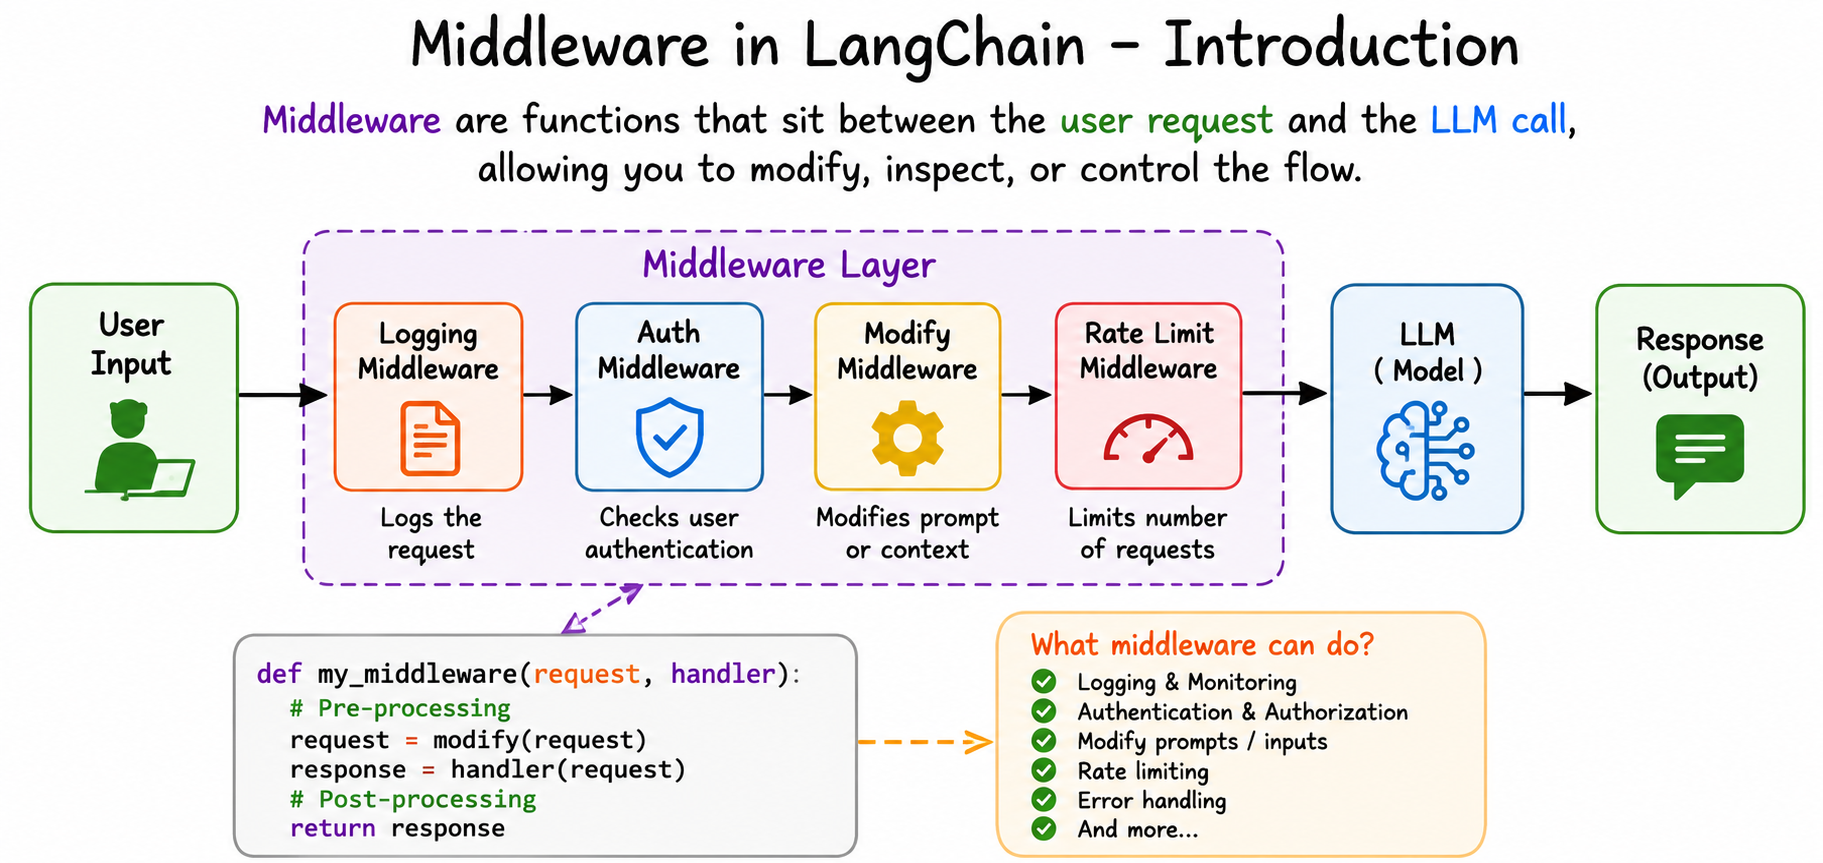

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


## Summarization MiddleWare
- Refer this link for more info: https://docs.langchain.com/oss/python/langchain/middleware/overview

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver 
from langchain_core.messages import HumanMessage, SystemMessage

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3-32b",
            trigger=("messages", 10),
            keep=("messages", 4)
        )

    ]
)

In [5]:
## Run with thread id

config ={
    "configurable":{
        "thread_id":"test-1"
    }
}

In [17]:
questions = [
    "what is 2+2?"
    "what is 12-2?"
    "what is 2+22?"
    "what is 2+78?"
    "what is 20*4?"
    "what is 12/2?"
]

for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]}, config)
    print(f"Messages:{response}", end="\n")
    
    print(f"Messages: {len(response['messages'])}", end="\n")
    print("-" * 40)
    


Messages:{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n<think>\nOkay, let\'s see. The user is asking the same set of math problems again. They\'ve been doing this multiple times now. Each time, the assistant answers them in the same way. The user\'s pattern is pretty clear—they\'re repeating the same questions.\n\nThe session intent here is probably for the user to get the correct answers to these basic arithmetic problems through repetition. They might be practicing, testing the AI\'s consistency, or just want to confirm their own answers each time.\n\nLooking at the summary, the key points are the repeated questions and the consistent responses. The assistant has always provided the same answers, which are correct. The reasoning behind not changing the format is to maintain consistency and avoid confusing the user. The next steps involve continuing to answer the same questions as they come up again.\n\nArtifacts aren\'t an issue here since ther

## Human In the Loop MiddleWare

- https://docs.langchain.com/oss/python/langchain/human-in-the-loop

- https://reference.langchain.com/python/langchain/agents/middleware/human_in_the_loop/HumanInTheLoopMiddleware

In [18]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [20]:
agent=create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)

In [21]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [22]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='75b33c45-05f9-4fa1-b9b9-50e3cdca276d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's a send_email_tool that requires recipient, subject, and body. All three are required. The parameters are provided in the user's message, so I can use that function. No need to read an email here. Just call send_email_tool with the given details.\n", 'tool_calls': [{'id': 'bpa1ze5xm', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 251, 'total_tokens': 382, 'completion_time': 0.221191092, 'completion_tokens

In [23]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email has been successfully sent to john@test.com with the subject "Hello". Let me know if you need anything else!


In [24]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='75b33c45-05f9-4fa1-b9b9-50e3cdca276d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's a send_email_tool that requires recipient, subject, and body. All three are required. The parameters are provided in the user's message, so I can use that function. No need to read an email here. Just call send_email_tool with the given details.\n", 'tool_calls': [{'id': 'bpa1ze5xm', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 251, 'total_tokens': 382, 'completion_time': 0.221191092, 'completion_tokens

# Reject

In [27]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [32]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [33]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='08a25be2-0f80-4b9e-ab65-0258d02f346d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's a send_email_tool that requires recipient, subject, and body. I need to make sure all required parameters are provided. The user provided all three: recipient is john@test.com, subject is Hello, body is How are you?. So I should call the send_email_tool with these arguments. No need to use the read_email_tool here since the task is about sending, not reading. Just format the tool_call correctly with the parameters.\n", 'tool_calls': [{'id': 's3z2380np', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'typ

In [34]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email to john@test.com was not sent as you rejected the initial request. Would you like me to:

1. Resend the email with the same details?
2. Modify the email content/recipient before sending?
3. Assist with a different task instead?

Let me know how you'd like to proceed!


In [35]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='08a25be2-0f80-4b9e-ab65-0258d02f346d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's a send_email_tool that requires recipient, subject, and body. I need to make sure all required parameters are provided. The user provided all three: recipient is john@test.com, subject is Hello, body is How are you?. So I should call the send_email_tool with these arguments. No need to use the read_email_tool here since the task is about sending, not reading. Just format the tool_call correctly with the parameters.\n", 'tool_calls': [{'id': 's3z2380np', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'typ

# Editing

In [36]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [37]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [38]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='1d74c986-efe8-4b87-90ca-64cab6f18854'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, let's see. The user wants to send an email to wrong@email.com with the subject 'Test' and body 'Hello'. I need to check which tool to use here. The available tools are read_email_tool and send_email_tool. Since the user is asking to send an email, the send_email_tool is the right choice.\n\nLooking at the parameters for send_email_tool, it requires recipient, subject, and body. The user provided all three: recipient is wrong@email.com, subject is 'Test', and body is 'Hello'. So I need to structure the arguments correctly. The parameters are all required, so I just need to map them directly. I'll make sure the JSON object includes all three fields with the correct values. No need for any additional parameters here. Let me doubl

In [39]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: The email has been successfully sent to **correct@email.com** with the subject "Corrected Subject". The body was edited to:  
"This was edited by human before sending". Let me know if you need anything else!


In [40]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='1d74c986-efe8-4b87-90ca-64cab6f18854'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, let's see. The user wants to send an email to wrong@email.com with the subject 'Test' and body 'Hello'. I need to check which tool to use here. The available tools are read_email_tool and send_email_tool. Since the user is asking to send an email, the send_email_tool is the right choice.\n\nLooking at the parameters for send_email_tool, it requires recipient, subject, and body. The user provided all three: recipient is wrong@email.com, subject is 'Test', and body is 'Hello'. So I need to structure the arguments correctly. The parameters are all required, so I just need to map them directly. I'll make sure the JSON object includes all three fields with the correct values. No need for any additional parameters here. Let me doubl